In [17]:
# Uncomment this in a fresh notebook environment.
#%pip install -r ../requirements.txt

In [18]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [19]:
import simulation_generator
import traffic_env

importlib.reload(simulation_generator)
importlib.reload(traffic_env)

from simulation_generator import SimulationGenerator
from traffic_env import SumoTrafficEnv
from statistics import mean
import matplotlib.pyplot as plt

## Generate the SUMO simulation files

The default network is a `4x4` SUMO grid with four signalized center junctions: `B1`, `B2`, `C1`, and `C2`. Each traffic light becomes one MARL agent.

In [20]:
generator = SimulationGenerator(
    output_dir=PROJECT_ROOT / "outputs" / "main_flow",
    grid_number=4,
    lane_number=1,
    traffic_light_ids=("B1", "B2", "C1", "C2"),
    trip_begin=0,
    trip_end=1000,
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()
print("Generated network:", paths.network_file)
print("Requested traffic-light agents:", generator.traffic_light_ids)

Generated network: C:\Code\marl-tsc\outputs\main_flow\network.net.xml
Requested traffic-light agents: ('B1', 'B2', 'C1', 'C2')


## Create the PettingZoo environment

`SumoTrafficEnv` starts SUMO through TraCI, discovers SUMO traffic light IDs, and treats each traffic light as one PettingZoo agent.

For the first version, each agent observes queue counts on its controlled lanes. Observations are normalized and padded to a fixed length so reinforcement learning libraries can consume them.

In [21]:
env = SumoTrafficEnv(
    config_file=paths.config_file,
    max_steps=100,
    seconds_per_action=5,
    max_lanes_per_tls=16,
    seed=42,
    render_mode=None,  # use "human" to run sumo-gui for visual debugging
)

observations, infos = env.reset(seed=42)
print("Agents:", env.agents)
print("Number of agents:", len(env.agents))
print("First observation shape:", next(iter(observations.values())).shape if observations else None)
env.close()

Agents: ['B1', 'B2', 'C1', 'C2']
Number of agents: 4
First observation shape: (16,)


## Smoke test with random actions

Before training, always check that random actions can run through the environment. This is much easier to debug than a failed training run.

The reward is currently the negative total queue length around each traffic light, so less negative is better.

In [22]:
env = SumoTrafficEnv(
    config_file=paths.config_file,
    max_steps=100,
    seconds_per_action=5,
    max_lanes_per_tls=16,
    seed=42,
)

observations, infos = env.reset(seed=42)
total_rewards = {agent: 0.0 for agent in env.agents}

for step in range(100):
    actions = {agent: env.action_space(agent).sample() for agent in env.agents}
    observations, rewards, terminations, truncations, infos = env.step(actions)

    for agent, reward in rewards.items():
        total_rewards[agent] += reward

    if not env.agents:
        break

env.close()

print("Completed random-action smoke test.")
print("Steps run:", step + 1)
print("Example total rewards:")
for agent, reward in list(total_rewards.items())[:5]:
    print(f"  {agent}: {reward:.1f}")

Completed random-action smoke test.
Steps run: 100
Example total rewards:
  B1: -78.0
  B2: -107.0
  C1: -73.0
  C2: -92.0


## Simple baseline controllers

In [23]:
def make_env(seed=42, max_steps=200):
    return SumoTrafficEnv(
        config_file=paths.config_file,
        max_steps=max_steps,
        seconds_per_action=5,
        max_lanes_per_tls=16,
        seed=seed,
    )


def random_controller(env, observations, step):
    return {agent: env.action_space(agent).sample() for agent in env.agents}


def fixed_cycle_controller(env, observations, step, phase_hold_steps=4):
    actions = {}
    for agent in env.agents:
        action_count = env.action_space(agent).n
        actions[agent] = (step // phase_hold_steps) % action_count
    return actions


def run_episode(controller, seed=42, max_steps=200):
    env = make_env(seed=seed, max_steps=max_steps)
    observations, infos = env.reset(seed=seed)
    total_rewards = {agent: 0.0 for agent in env.agents}
    mean_reward_by_step = []

    try:
        for step in range(max_steps):
            actions = controller(env, observations, step)
            observations, rewards, terminations, truncations, infos = env.step(actions)

            if rewards:
                mean_reward_by_step.append(mean(rewards.values()))

            for agent, reward in rewards.items():
                total_rewards[agent] += reward

            if not env.agents:
                break
    finally:
        env.close()

    return {
        "steps": step + 1,
        "total_network_reward": sum(total_rewards.values()),
        "average_step_reward": mean(mean_reward_by_step) if mean_reward_by_step else 0.0,
        "per_agent_rewards": total_rewards,
    }

## Controller comparison

These are not trained policies. They are simple baselines to confirm the multi-agent environment runs before adding a MARL algorithm.

Running random controller...
Running fixed_cycle controller...

Controller comparison
------------------------------------------------------------------------
Controller          Steps       Total reward    Avg step reward
------------------------------------------------------------------------
random                200             -755.0              -0.94
fixed_cycle           200             -763.0              -0.95


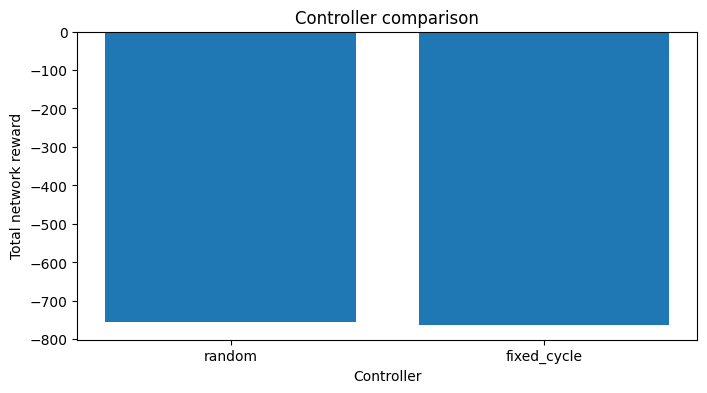

In [24]:
controllers = {
    "random": random_controller,
    "fixed_cycle": fixed_cycle_controller,
}

results = {}

for name, controller in controllers.items():
    print(f"Running {name} controller...")
    results[name] = run_episode(controller, seed=42, max_steps=200)

print("\nController comparison")
print("-" * 72)
print(f"{'Controller':<16} {'Steps':>8} {'Total reward':>18} {'Avg step reward':>18}")
print("-" * 72)

for name, result in results.items():
    print(
        f"{name:<16} "
        f"{result['steps']:>8} "
        f"{result['total_network_reward']:>18.1f} "
        f"{result['average_step_reward']:>18.2f}"
    )

names = list(results.keys())
scores = [results[name]["total_network_reward"] for name in names]

plt.figure(figsize=(8, 4))
plt.bar(names, scores)
plt.title("Controller comparison")
plt.xlabel("Controller")
plt.ylabel("Total network reward")
plt.show()